In [9]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as sla
import warnings
import scipy.integrate as integrate
from scipy.interpolate import pade
from scipy.signal import residue
from scipy.linalg import matmul_toeplitz
from scipy.integrate import quad
from tqdm import tqdm

# FUNCTIONS

In [11]:
# ==========================================
# 1. HELPER FUNCTIONS & INVERSE LAPLACE
# ==========================================
def coth(z):
    z = np.asarray(z, dtype=np.complex128)
    out = np.empty_like(z)

    r = np.real(z)

    pos = r > 20
    neg = r < -20
    mid = ~(pos | neg)

    out[pos] = 1.0 + 2*np.exp(-2*z[pos])
    out[neg] = -1.0 - 2*np.exp(2*z[neg])
    out[mid] = np.cosh(z[mid])/np.sinh(z[mid])

    return out.item() if out.ndim == 0 else out


def csch2(z):
    z = np.asarray(z, dtype=np.complex128)
    out = np.empty_like(z)

    r = np.real(z)

    large = np.abs(r) > 20
    small = ~large

    out[large] = 4*np.exp(-2*np.abs(r[large]))*np.exp(-2j*np.imag(z[large])*0)

    s = np.sinh(z[small])
    out[small] = 1/(s*s)

    return out.item() if out.ndim == 0 else out

def inverse_laplace_rational(B, A, enforce_real=True):
    B = np.atleast_1d(np.array(B, dtype=np.complex128))
    A = np.atleast_1d(np.array(A, dtype=np.complex128))
    r, p, k = residue(B, A)

    info = {"residues": r, "poles": p, "direct_poly": k}
    return info

def derivatives_from_residues(t, residues, poles, enforce_real=True):
    t = np.asarray(t, dtype=float)

    G    = np.zeros_like(t, dtype=np.complex128)
    Gdot = np.zeros_like(t, dtype=np.complex128)
    Gddot= np.zeros_like(t, dtype=np.complex128)

    for r, p in zip(residues, poles):
        ep = np.exp(p * t)
        G     += r * ep
        Gdot  += r * p * ep
        Gddot += r * p * p * ep

    if enforce_real:
        G     = np.real_if_close(G)
        Gdot  = np.real_if_close(Gdot)
        Gddot = np.real_if_close(Gddot)

    return G, Gdot, Gddot

# ==========================================
# 2. NOISE KERNEL & TEMPERATURE DERIVATIVE
# ==========================================
def noise_kernel_residue(t, gamma, alpha1, alpha2, Temp, Nmats=65000, delta_eps=1e-10):
    scalar_input = np.isscalar(t)
    t = np.atleast_1d(np.asarray(t, dtype=np.float64))
    t = np.abs(t)
    
    Delta = 4.0 * alpha2 * gamma - gamma**2
    beta = 1.0 / Temp
    a = 0.5 * beta

    if abs(Delta) < delta_eps:
        w0 = 0.5j * gamma
        exp0 = np.exp(1j * w0 * t)
        coth0 = coth(a * w0)
        fprime = (a * (-csch2(a * w0)) + 1j * t * coth0) * exp0
        nu_sys = (np.pi * gamma * alpha1 * alpha2 / 2.0) * np.real(fprime)
    else:
        sqrtDelta = np.sqrt(Delta + 0j)  
        w_plus  = 0.5j * gamma + 0.5 * sqrtDelta
        w_minus = 0.5j * gamma - 0.5 * sqrtDelta
        term_plus  = coth(a * w_plus)  * np.exp(1j * w_plus  * t)
        term_minus = coth(a * w_minus) * np.exp(1j * w_minus * t)
        pref = ( gamma * alpha1 * alpha2) / (2.0 * sqrtDelta)
        nu_sys = np.real(pref * (term_plus - term_minus))

    n = np.arange(1, Nmats+1, dtype=np.float64)
    nu_n = (2.0 * np.pi / beta) * n
    denom = (alpha2 * gamma + nu_n**2)**2 - (gamma * nu_n)**2
    expo = np.exp(-nu_n[:, None] * t[None, :])
    mats_sum = (nu_n / denom)[:, None] * expo
    nu_M = -(2.0  * gamma**2 * alpha1 * alpha2 / beta) * mats_sum.sum(axis=0)

    out = (nu_sys + nu_M)
    return float(out[0]) if scalar_input else out

def dnu_dT_residue(t, gamma, alpha1, alpha2, Temp, Nmats=65000, delta_eps=1e-10):
    scalar_input = np.isscalar(t)
    t = np.atleast_1d(np.asarray(t, dtype=np.float64))
    t = np.abs(t)
    
    Delta = 4.0 * alpha2 * gamma - gamma**2
    beta = 1.0 / Temp
    T2 = Temp**2

    if abs(Delta) < delta_eps:
        w0 = 0.5j * gamma
        a = 0.5 * beta
        exp0 = np.exp(1j * w0 * t)
        nu_sys_deriv = (np.pi * gamma * alpha1 * alpha2 / (4.0 * T2)) * np.real(w0 * csch2(a * w0) * exp0) 
    else:
        sqrtDelta = np.sqrt(Delta + 0j)  
        w_plus  = 0.5j * gamma + 0.5 * sqrtDelta
        w_minus = 0.5j * gamma - 0.5 * sqrtDelta
        term_plus  = w_plus * csch2(0.5 * beta * w_plus) * np.exp(1j * w_plus * t)
        term_minus = w_minus * csch2(0.5 * beta * w_minus) * np.exp(1j * w_minus * t)
        pref = -(gamma * alpha1 * alpha2) / (4.0 * T2 * sqrtDelta)
        nu_sys_deriv = np.real(pref * (term_plus - term_minus))

    k = np.arange(1, Nmats + 1, dtype=np.float64)
    fk = (2.0 * np.pi / beta) * k
    
    denom = (alpha2 * gamma + fk**2)**2 - (gamma * fk)**2
    expo = np.exp(-fk[:, None] * t[None, :])
    
    term_A_sum = (fk[:, None] / denom[:, None]) * expo
    term_A = - (2.0 * gamma**2 * alpha1 * alpha2) * term_A_sum.sum(axis=0)
    
    num_part1 = expo * (1 - t[None, :] * fk[:, None]) * denom[:, None]

    # Calculate the purely k-dependent polynomial in 1D first
    inner_k_term = 4 * fk * (alpha2 * gamma + fk**2) - 2 * gamma**2 * fk

    # Then broadcast it against the time-dependent expo matrix
    num_part2 = fk[:, None] * expo * inner_k_term[:, None]
    term_B_sum = k[:, None] * ((num_part1 - num_part2) / (denom[:, None]**2))
    term_B = - (4.0 * np.pi * gamma**2 * alpha1 * alpha2 / beta) * term_B_sum.sum(axis=0)

    nu_M_deriv = term_A + term_B
    out = nu_sys_deriv + nu_M_deriv
    
    return float(out[0]) if scalar_input else out

# Variances and Dynamical CFI

Simulating Dynamics & FI: 100%|██████████| 9999/9999 [01:37<00:00, 102.70it/s]


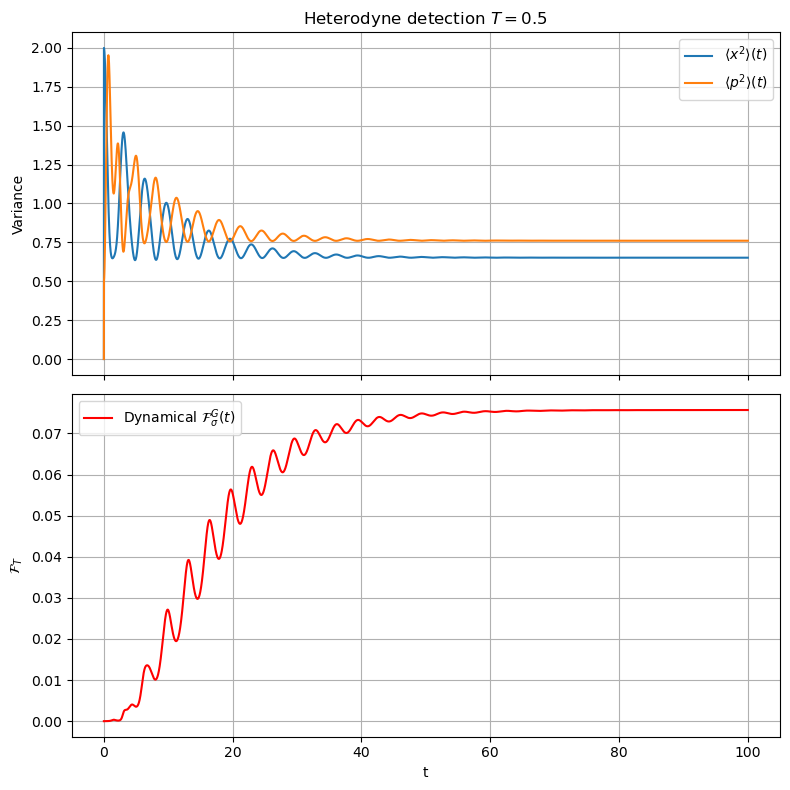

In [4]:
def evolve_FI_dynamics(t_array,x0, p0, sigma0, sigma_M, alpha1, alpha2, Temp, gamma, G, Gdot, mass=1.0):
    dt = t_array[1] - t_array[0]
    N = len(t_array)
    
    G_r = G.real
    Gdot_r = Gdot.real
    Gddot_r = Gddot.real

    x_mean = Gdot_r * x0 + (G_r / mass) * p0
    p_mean = mass * Gddot_r * x0 + Gdot_r * p0
    # System contribution to Covariance (Constant T-derivative = 0)
    sx0, sp0, sxp0 = sigma0[0, 0], sigma0[1, 1], sigma0[0, 1]
    var_x_sys = (Gdot_r**2) * sx0 + (G_r / mass)**2 * sp0 + 2 * Gdot_r * (G_r / mass) * sxp0
    a, b = mass * Gddot_r, Gdot_r 
    var_p_sys = (a**2) * sx0 + (b**2) * sp0 + 2 * a * b * sxp0
    cov_xp_sys = Gdot_r * a * sx0 + (G_r/mass) * b * sp0 + (Gdot_r * b + (G_r/mass)*a)*sxp0

    # Precompute noise kernel and its Temperature derivative
    nu_grid = np.array([noise_kernel_residue(t, gamma, alpha1, alpha2, Temp) for t in t_array]) / mass
    dnu_grid = dnu_dT_residue(t_array, gamma, alpha1, alpha2, Temp) / mass 

    fisher_info_t = np.zeros(N)
    var_x_total = np.zeros(N)
    var_p_total = np.zeros(N)
    
    for i in tqdm(range(1, N), desc="Simulating Dynamics & FI"):
        G_slice = G_r[:i+1][::-1] 
        Gd_slice = Gdot_r[:i+1][::-1] 
        
        nu_seg = nu_grid[:i+1]  
        dnu_seg = dnu_grid[:i+1]
        
        # Standard Covariance Integrals (Toeplitz)
        yG = matmul_toeplitz((nu_seg, nu_seg), G_slice)
        yGd = matmul_toeplitz((nu_seg, nu_seg), Gd_slice)
        
        var_x_bath = np.dot(G_slice, yG) * dt**2
        var_p_bath = np.dot(Gd_slice, yGd) * dt**2
        cov_xp_bath = np.dot(G_slice, yGd) * dt**2
        
        sigma_t = np.array([
            [var_x_sys[i] + var_x_bath, cov_xp_sys[i] + cov_xp_bath],
            [cov_xp_sys[i] + cov_xp_bath, var_p_sys[i] + var_p_bath]
        ])
        
        var_x_total[i] = sigma_t[0, 0]
        var_p_total[i] = sigma_t[1, 1]
        
        # Derivative Covariance Integrals (Toeplitz)
        dyG = matmul_toeplitz((dnu_seg, dnu_seg), G_slice)
        dyGd = matmul_toeplitz((dnu_seg, dnu_seg), Gd_slice)
        
        dvar_x_bath = np.dot(G_slice, dyG) * dt**2
        dvar_p_bath = np.dot(Gd_slice, dyGd) * dt**2
        dcov_xp_bath = np.dot(G_slice, dyGd) * dt**2
        
        dsigma_t = np.array([
            [dvar_x_bath, dcov_xp_bath],
            [dcov_xp_bath, dvar_p_bath]
        ])
        
        # Calculate Fisher Information Term
        inverse_term = np.linalg.inv(sigma_t + sigma_M)
        matrix_prod = np.dot(inverse_term, dsigma_t)
        fisher_info_t[i] = 0.5 * np.trace(np.dot(matrix_prod, matrix_prod))
            
    return {"time": t_array, "x_mean": x_mean, "var_x": var_x_total, "p_mean": p_mean, "var_p": var_p_total, "FI": fisher_info_t}


# ==========================================
# 4. EXECUTION BLOCK
# ==========================================
if __name__ == "__main__":
    # --- Physical Parameters (Replace with your actual values) ---
    gamma = 1.0
    alpha1 = 1.0
    alpha2 = 10.0
    Omega_S_bare = 1.0
    delta_Omega_s = np.sqrt(alpha1)
    Omega_S = np.sqrt(Omega_S_bare**2 + delta_Omega_s**2)
    temp = 0.5
    mass = 1.0
    
    # Simulation Time Grid
    times = np.linspace(0, 100, 10000)
    
    # Laplace Polynomials for the Green's Function
    B = [1, gamma, alpha2 * gamma]
    A = [1, gamma, alpha2 * gamma + Omega_S**2, gamma * Omega_S**2, alpha2 * gamma * Omega_S**2 - gamma * alpha1 * alpha2]
    
    # Extract Green's Function and Derivative
    info = inverse_laplace_rational(B, A)
    G, Gprime_of_t, Gddot = derivatives_from_residues(times, info["residues"], info["poles"])

    # evaluate inverse Laplace
    Gdot = Gprime_of_t
    
    x0 = 1.0
    p0 = 0.0
    
    sigma0 = np.array([[2.0 / Omega_S_bare, 0], 
                       [0, Omega_S_bare / 2.0]])
    
    # ---------------------------------------------------------
    # DEFINE YOUR MEASUREMENT NOISE MATRIX HERE
    # Example 1: Homodyne (x-quadrature measurement) 
    sigma_M = np.array([[1e6, 0.0], [0.0, 0.0]])  # Large noise on p
    # Example 2: Heterodyne (symmetric measurement)
    #sigma_M = np.array([[0.5, 0.0], [0.0, 0.5]])
    # ---------------------------------------------------------

    # Run Simulation
    # Run Simulation
    sol = evolve_FI_dynamics(times,x0, p0, sigma0, sigma_M, alpha1, alpha2, temp, gamma, G, Gdot, mass)

   # ==========================================
    # 5. PLOT RESULTS WITH ASYMPTOTES
    # ==========================================
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
    
    # Calculate asymptotic thermal values (High-T limit, Omega_S = 1)
    thermal_variance = temp  
    thermal_FI = 1.0 / (temp + 0.5)**2  # Valid for Heterodyne detection

    # Variance Plot (ax1)
    ax1.plot(sol["time"], sol["var_x"], label=r"$\langle x^2 \rangle(t)$")
    ax1.plot(sol["time"], sol["var_p"], label=r"$\langle p^2 \rangle(t)$")
    
    ax1.set_ylabel("Variance")
    ax1.legend()
    ax1.grid(True)
    ax1.set_title(rf"Heterodyne detection $T={temp}$")
    
    # Fisher Information Plot (ax2)
    ax2.plot(sol["time"], sol["FI"], color='red', label=r"Dynamical $\mathcal{F}_\sigma^G(t)$")
    
    if temp > 19:
        ax1.axhline(thermal_variance, color='black', linestyle='--', alpha=0.7, label=rf"Thermal Asymptote ($T={temp}$)")
        ax2.axhline(thermal_FI, color='black', linestyle='--', alpha=0.7, label=r"Thermal Asymptote $\mathcal{F}_{th}$")
    
    ax2.set_xlabel("t")
    ax2.set_ylabel(r"$\mathcal{F}_T$")
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

# Dynamical QFI (T)


--- Simulando para T = 0.01 ---


Simulating Dynamics & FI: 100%|██████████| 499/499 [00:01<00:00, 285.46it/s]



--- Simulando para T = 1.0 ---


Simulating Dynamics & FI: 100%|██████████| 499/499 [00:01<00:00, 255.69it/s]



--- Simulando para T = 3.0 ---


Simulating Dynamics & FI: 100%|██████████| 499/499 [00:01<00:00, 291.94it/s]



--- Simulando para T = 20.0 ---


Simulating Dynamics & FI: 100%|██████████| 499/499 [00:01<00:00, 361.82it/s]


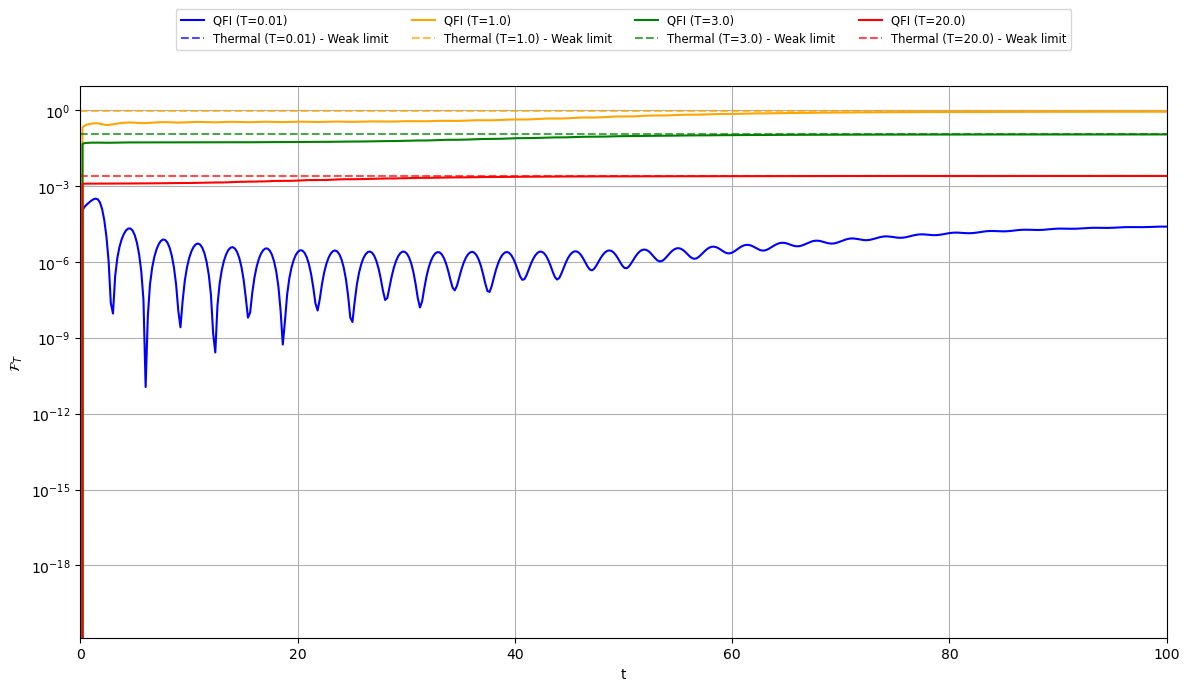

In [22]:
def evolve_FI_dynamics(t_array,x0, p0, sigma0, sigma_M, alpha1, alpha2, Temp, gamma, G, Gdot, mass=1.0):
    dt = t_array[1] - t_array[0]
    N = len(t_array)
    
    G_r = G.real
    Gdot_r = Gdot.real
    Gddot_r = Gddot.real


    x_mean = Gdot_r * x0 + (G_r / mass) * p0
    p_mean = mass * Gddot_r * x0 + Gdot_r * p0
    # System contribution to Covariance (Constant T-derivative = 0)
    sx0, sp0, sxp0 = sigma0[0, 0], sigma0[1, 1], sigma0[0, 1]
    var_x_sys = (Gdot_r**2) * sx0 + (G_r / mass)**2 * sp0 + 2 * Gdot_r * (G_r / mass) * sxp0
    a, b = mass * Gddot_r, Gdot_r 
    var_p_sys = (a**2) * sx0 + (b**2) * sp0 + 2 * a * b * sxp0
    cov_xp_sys = Gdot_r * a * sx0 + (G_r/mass) * b * sp0 + (Gdot_r * b + (G_r/mass)*a)*sxp0

    # Precompute noise kernel and its Temperature derivative
    nu_grid = np.array([noise_kernel_residue(t, gamma, alpha1, alpha2, Temp) for t in t_array]) / mass
    dnu_grid = dnu_dT_residue(t_array, gamma, alpha1, alpha2, Temp) / mass 

    fisher_info_t = np.zeros(N)
    var_x_total = np.zeros(N)
    var_p_total = np.zeros(N)
    QFI = np.zeros(N)

    #QFI
    Omega_symp = np.array([[0, 1], [-1, 0]])
    kron_omega = np.kron(Omega_symp, Omega_symp)
    
    for i in tqdm(range(1, N), desc="Simulating Dynamics & FI"):
        G_slice = G_r[:i+1][::-1] 
        Gd_slice = Gdot_r[:i+1][::-1] 
        
        nu_seg = nu_grid[:i+1]  
        dnu_seg = dnu_grid[:i+1]
        
        # Standard Covariance Integrals (Toeplitz)
        yG = matmul_toeplitz((nu_seg, nu_seg), G_slice)
        yGd = matmul_toeplitz((nu_seg, nu_seg), Gd_slice)
        
        var_x_bath = np.dot(G_slice, yG) * dt**2
        var_p_bath = np.dot(Gd_slice, yGd) * dt**2
        cov_xp_bath = np.dot(G_slice, yGd) * dt**2
        
        sigma_t = np.array([
            [var_x_sys[i] + var_x_bath, cov_xp_sys[i] + cov_xp_bath],
            [cov_xp_sys[i] + cov_xp_bath, var_p_sys[i] + var_p_bath]
        ])
        
        var_x_total[i] = sigma_t[0, 0]
        var_p_total[i] = sigma_t[1, 1]
        
        # Derivative Covariance Integrals (Toeplitz)
        dyG = matmul_toeplitz((dnu_seg, dnu_seg), G_slice)
        dyGd = matmul_toeplitz((dnu_seg, dnu_seg), Gd_slice)
        
        dvar_x_bath = np.dot(G_slice, dyG) * dt**2
        dvar_p_bath = np.dot(Gd_slice, dyGd) * dt**2
        dcov_xp_bath = np.dot(G_slice, dyGd) * dt**2
        
        dsigma_t = np.array([
            [dvar_x_bath, dcov_xp_bath],
            [dcov_xp_bath, dvar_p_bath]
        ])
        
        # Calculate Fisher Information Term
        inverse_term = np.linalg.inv(sigma_t + sigma_M)
        matrix_prod = np.dot(inverse_term, dsigma_t)
        fisher_info_t[i] = 0.5 * np.trace(np.dot(matrix_prod, matrix_prod))

        # Calculate QFI with a Truncated Spectral Inverse
        kron_sigma = np.kron(sigma_t, sigma_t)
        M = kron_sigma - 0.25*kron_omega
        
        # 1. Get exact eigenvalues and eigenvectors (M is symmetric)
        evals, evecs = np.linalg.eigh(M)
        
        # 2. Filter out unphysical negative values and dangerously small positive ones.
        # Any eigenvalue < 1e-7 is numerical noise crossing the pure state boundary.
        threshold = 1e-7
        evals_inv = np.where(evals > threshold, 1.0 / evals, 0.0)
        
        # 3. Reconstruct the perfectly stable inverse matrix
        M_inv = evecs @ np.diag(evals_inv) @ evecs.T
        
        dsigma_vec = dsigma_t.flatten(order='F') 
        QFI[i] = 0.5 * np.dot(dsigma_vec.T, np.dot(M_inv, dsigma_vec))
            
    return {"time": t_array, "var_x": var_x_total, "var_p": var_p_total, "FI": fisher_info_t, "QFI": QFI}


# ==========================================
# 4. EXECUTION BLOCK
# ==========================================
if __name__ == "__main__":
    # --- Physical Parameters (Replace with your actual values) ---
    gamma = 1.0
    alpha1 = 0.1
    alpha2 = 2.0
    Omega_S_bare = 1.0
    delta_Omega_s = np.sqrt(alpha1)
    Omega_S = np.sqrt(Omega_S_bare**2 + delta_Omega_s**2)
    mass = 1.0
    
    # Simulation Time Grid
    times = np.linspace(0, 100, 500)
    
    # Laplace Polynomials for the Green's Function
    B = [1, gamma, alpha2 * gamma]
    A = [1, gamma, alpha2 * gamma + Omega_S**2, gamma * Omega_S**2, alpha2 * gamma * Omega_S**2 - gamma * alpha1 * alpha2]
    
    # Extract Green's Function and Derivative
    info = inverse_laplace_rational(B, A)
    G, Gprime_of_t, Gddot = derivatives_from_residues(times, info["residues"], info["poles"])

    # evaluate inverse Laplace
    Gdot = Gprime_of_t
    
    x0 = 1.0
    p0 = 0.0

    sigma0 = np.array([[100, 0], 
                       [0, 1/400]])
    
    # ---------------------------------------------------------
    # DEFINE YOUR MEASUREMENT NOISE MATRIX HERE
    # Example 1: Homodyne (x-quadrature measurement) 
    sigma_M = np.array([[1/2, 0.0], [0.0, 1/2]])  # Large noise on p
    # Example 2: Heterodyne (symmetric measurement)
    #sigma_M = np.array([[0.5, 0.0], [0.0, 0.5]])
    # ---------------------------------------------------------

    # ==========================================
    # 5. LOOP OVER TEMPERATURES & PLOT RESULTS
    # ==========================================
    temperaturas = [0.01, 1.0, 3.0, 20.0]
    colores = ['blue', 'orange', 'green', 'red']
    
    plt.figure(figsize=(12, 7))

    for temp, color in zip(temperaturas, colores):
        print(f"\n--- Simulando para T = {temp} ---")
        
        # Run Simulation for current temperature
        sol = evolve_FI_dynamics(times, x0, p0, sigma0, sigma_M, alpha1, alpha2, temp, gamma, G, Gdot, mass)

        # Thermal Asymptote (Valid for HO but JUST AT WEAKLY COUPLING!!)
        thermal_QFI = 0.25 * (Omega_S**2 / temp**4) * csch2(Omega_S / (2 * temp)) 
        
        # Plot QFI and its corresponding thermal asymptote
        plt.plot(sol["time"], sol["QFI"], color=color, label=f"QFI (T={temp})")
        plt.axhline(thermal_QFI, color=color, linestyle='--', alpha=0.7, label=f"Thermal (T={temp}) - Weak limit")

    # Formatting the plot
    plt.xlabel("t")
    plt.ylabel(r"$\mathcal{F}_T$")
    
    plt.yscale('log')

    # Opcional: Ajustar los límites para que no empiece desde un valor negativo imposible
    # La escala logarítmica no admite valores <= 0, si tu QFI toca el cero, 
    # ajustamos el límite inferior manualmente:
    plt.xlim(0, 100)

    # Ajustamos la leyenda fuera del gráfico para que no tape las curvas si son muchas
    plt.legend(
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.15), 
    ncol=4, 
    fontsize='small'
    )
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

# Interaction Picture

Simulating Dynamics & FIs: 100%|██████████| 999/999 [00:01<00:00, 609.81it/s]


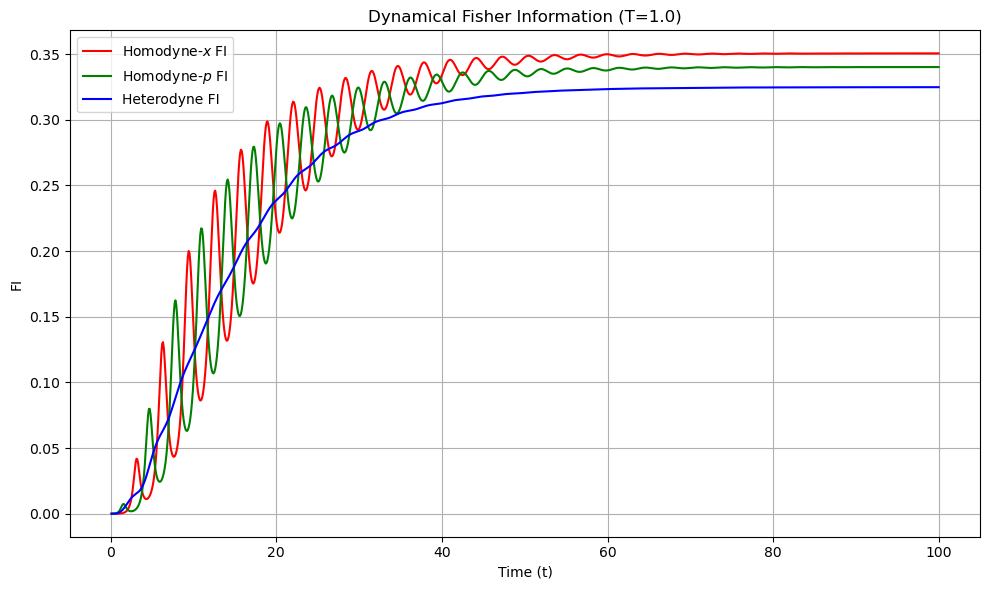

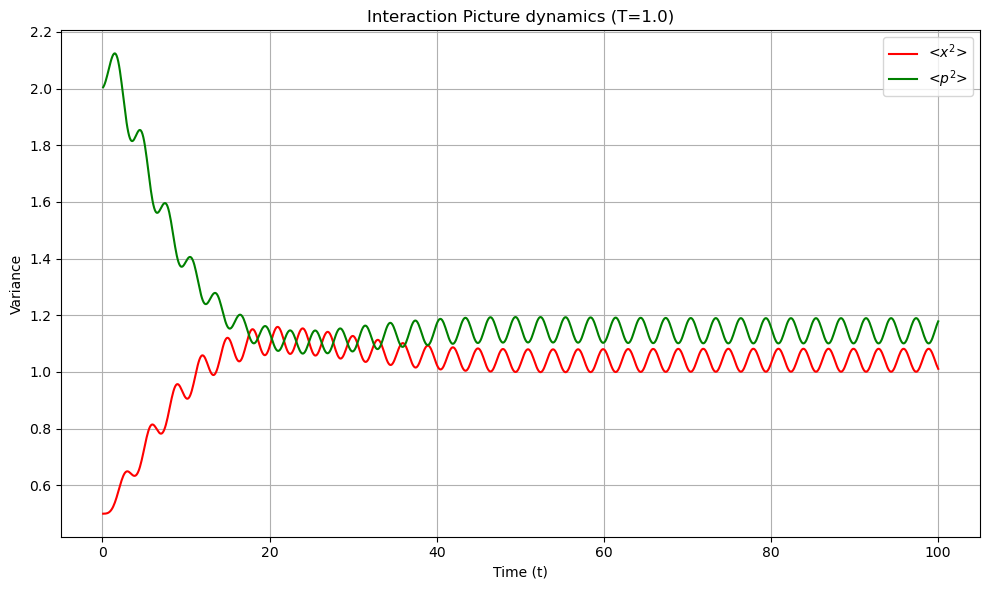

In [6]:
def evolve_all_FI_dynamics(t_array,x0, p0, sigma0, alpha1, alpha2, Temp, gamma, G, Gdot, Omega_S, mass=1.0):
    dt = t_array[1] - t_array[0]
    N = len(t_array)
    
    G_r = G.real
    Gdot_r = Gdot.real
    Gddot_r = Gddot.real
    
    x_mean = Gdot_r * x0 + (G_r / mass) * p0
    p_mean = mass * Gddot_r * x0 + Gdot_r * p0
    # System contribution to Covariance (Constant T-derivative = 0)
    sx0, sp0, sxp0 = sigma0[0, 0], sigma0[1, 1], sigma0[0, 1]
    var_x_sys = (Gdot_r**2) * sx0 + (G_r / mass)**2 * sp0 + 2 * Gdot_r * (G_r / mass) * sxp0
    a, b = mass * Gddot_r, Gdot_r 
    var_p_sys = (a**2) * sx0 + (b**2) * sp0 + 2 * a * b * sxp0
    cov_xp_sys = Gdot_r * a * sx0 + (G_r/mass) * b * sp0 + (Gdot_r * b + (G_r/mass)*a)*sxp0

    # Precompute noise kernel and its Temperature derivative
    nu_grid = np.array([noise_kernel_residue(t, gamma, alpha1, alpha2, Temp) for t in t_array]) / mass
    dnu_grid = dnu_dT_residue(t_array, gamma, alpha1, alpha2, Temp) / mass 

    # Arrays to store tracking variables
    var_x_total, var_p_total, FI_het, FI_hom_x, FI_hom_p, QFI = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)
    
    # Define Measurement Matrices
    sig_M_het = np.array([[0.5, 0.0], [0.0, 0.5]])
    sig_M_hom_x = np.array([[0.0, 0.0], [0.0, 1e8]]) # Infinite noise on p
    sig_M_hom_p = np.array([[1e8, 0.0], [0.0, 0.0]]) # Infinite noise on x

    # Thermal values for the FI
    FI_th_het = 0.5 * ((1/(Temp+sig_M_het[0,0]*Omega_S)**2)+(1/(Temp+sig_M_het[1,1])**2))
    FI_th_hom_x = 0.5 * ((1/(Temp + sig_M_hom_x[0,0]*Omega_S)**2)+(1/(Temp + sig_M_hom_x[1,1])**2))
    FI_th_hom_p = 0.5 * ((1/(Temp + sig_M_hom_p[0,0]*Omega_S)**2)+(1/(Temp + sig_M_hom_p[1,1])**2))

    Omega_symp = np.array([[0, 1], [-1, 0]])
    kron_omega = np.kron(Omega_symp, Omega_symp)

    # CORRECTED: Backward Rotation Matrix U(-t) for Interaction Picture
    def get_R_back(t, m, w):
        return np.array([ [np.cos(w*t), -(1.0/(m*w)) * np.sin(w*t)], [m*w * np.sin(w*t),  np.cos(w*t)]])
        #return np.array([[ 1, 0],[0, 1]])

    def calc_classical_CFI(sig, dsig, sig_M):
        inv_term = np.linalg.inv(sig + sig_M)
        prod = np.dot(inv_term, dsig)
        return 0.5 * np.trace(np.dot(prod, prod))

    for i in tqdm(range(1, N), desc="Simulating Dynamics & FIs"):
        t_current = t_array[i]
        G_slice = G_r[:i+1][::-1] 
        Gd_slice = Gdot_r[:i+1][::-1] 
        nu_seg = nu_grid[:i+1]  
        dnu_seg = dnu_grid[:i+1]
        
        # Integrals (Toeplitz)
        yG = matmul_toeplitz((nu_seg, nu_seg), G_slice)
        yGd = matmul_toeplitz((nu_seg, nu_seg), Gd_slice)
        var_x_bath = np.dot(G_slice, yG) * dt**2
        var_p_bath = np.dot(Gd_slice, yGd) * dt**2
        cov_xp_bath = np.dot(G_slice, yGd) * dt**2

        dyG = matmul_toeplitz((dnu_seg, dnu_seg), G_slice)
        dyGd = matmul_toeplitz((dnu_seg, dnu_seg), Gd_slice)
        dvar_x_bath = np.dot(G_slice, dyG) * dt**2
        dvar_p_bath = np.dot(Gd_slice, dyGd) * dt**2
        dcov_xp_bath = np.dot(G_slice, dyGd) * dt**2

        sigma_t_lab = np.array([
            [var_x_sys[i] + var_x_bath, cov_xp_sys[i] + cov_xp_bath],
            [cov_xp_sys[i] + cov_xp_bath, var_p_sys[i] + var_p_bath]
        ])
        
        dsigma_t_lab = np.array([
            [dvar_x_bath, dcov_xp_bath],
            [dcov_xp_bath, dvar_p_bath]
        ])
        
        # --- SHIFT TO INTERACTION PICTURE ---
        R_t = get_R_back(t_current, mass, Omega_S) # Using correct renormalized Omega

        sigma_rot = np.dot(R_t, np.dot(sigma_t_lab, R_t.T))
        dsigma_rot = np.dot(R_t, np.dot(dsigma_t_lab, R_t.T))

        var_x_total[i] = sigma_rot[0, 0]
        var_p_total[i] = sigma_rot[1, 1]
        
        # Rotate the measurement matrix so the lab-frame physics is strictly preserved
        sig_M_het_rot = np.dot(R_t, np.dot(sig_M_het, R_t.T))
        sig_M_hom_x_rot = np.dot(R_t, np.dot(sig_M_hom_x, R_t.T))
        sig_M_hom_p_rot = np.dot(R_t, np.dot(sig_M_hom_p, R_t.T))

        # 1. Classical FIs
        FI_het[i] = calc_classical_CFI(sigma_rot, dsigma_rot, sig_M_het_rot)
        FI_hom_x[i] = calc_classical_CFI(sigma_rot, dsigma_rot, sig_M_hom_x_rot)
        FI_hom_p[i] = calc_classical_CFI(sigma_rot, dsigma_rot, sig_M_hom_p_rot)
        
        # 2. Quantum FI (Exact Bures metric formula)
        kron_sigma = np.kron(sigma_t_lab, sigma_t_lab)
        M_inv = np.linalg.inv(kron_sigma - kron_omega)
        dsigma_vec = dsigma_t_lab.flatten(order='F') 
        QFI[i] = 0.5 * np.dot(dsigma_vec.T, np.dot(M_inv, dsigma_vec))
        
    return {"time": t_array, "var_x": var_x_total, "var_p": var_p_total, "FI_het": FI_het, "FI_hom_x": FI_hom_x, "FI_hom_p": FI_hom_p, "QFI": QFI, "FI_th_het": FI_th_het, "FI_th_hom_x": FI_th_hom_x, "FI_th_hom_p": FI_th_hom_p,}

# ==========================================
# 4. EXECUTION BLOCK
# ==========================================
if __name__ == "__main__":
    gamma = 1.0
    alpha1 = 0.1
    alpha2 = 2.0
    Omega_S_bare = 1.0
    delta_Omega_s = np.sqrt(alpha1)
    Omega_S = np.sqrt(Omega_S_bare**2 + delta_Omega_s**2)
    temp = 1.0
    mass = 1.0
    Omega_IntPict = Omega_S
    
    times = np.linspace(0, 100, 1000)
    
    B = [1, gamma, alpha2 * gamma]
    A = [1, gamma, alpha2 * gamma + Omega_S**2, gamma * Omega_S**2, alpha2 * gamma * Omega_S**2 - gamma * alpha1 * alpha2]
    info = inverse_laplace_rational(B, A)
    G, Gprime_of_t, Gddot = derivatives_from_residues(times, info["residues"], info["poles"])

    # evaluate inverse Laplace
    Gdot = Gprime_of_t

    x0 = 1.0
    p0 = 0.0
    sigma0 = np.array([[Omega_S_bare/2, 0], 
                       [0, 2/Omega_S_bare]])
    
    sigma_M = np.array([[0.5, 0.0], [0.0, 0.5]])

    # CRITICAL: Pass the fully renormalized Omega_S here
    sol = evolve_all_FI_dynamics(times,x0, p0, sigma0, alpha1, alpha2, temp, gamma, G, Gdot, Omega_IntPict, mass)

   # ==========================================
    # --- 3. Plot Results ---
    
    plt.figure(figsize=(10, 6))
    
    # Dynamical Curves
    #plt.plot(sol["time"][1:], sol["QFI"][1:], color='black', linewidth=2.5, label=r"Quantum FI ($\mathcal{F}^Q$)")
    plt.plot(sol["time"][1:], sol["FI_hom_x"][1:], color='red', linewidth=1.5, label=r"Homodyne-$x$ FI")
    plt.plot(sol["time"][1:], sol["FI_hom_p"][1:], color='green', linewidth=1.5, label=r"Homodyne-$p$ FI")
    plt.plot(sol["time"][1:], sol["FI_het"][1:], color='blue', linewidth=1.5, label=r"Heterodyne FI")
    if temp > 19:
        plt.axhline(sol["FI_th_hom_x"], linestyle='--', alpha=0.2, color='black', linewidth=1.5)
        plt.axhline(sol["FI_th_hom_p"], linestyle='--', alpha=0.2, color='black', linewidth=1.5)
        plt.axhline(sol["FI_th_het"], linestyle='--', alpha=0.2, color='black', linewidth=1.5)
    #plt.axhline(QFI_th_HO, color='black', linestyle='--', alpha=0.7, label=r"Thermal Asymptote $\mathcal{F}_{th}$")
    
    plt.xlabel("Time (t)")
    plt.ylabel("FI")
    plt.title(rf"Dynamical Fisher Information (T={temp})")
    plt.legend(loc='best')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    

    plt.figure(figsize=(10, 6))
    plt.plot(sol["time"][1:], sol["var_x"][1:], color='red', linewidth=1.5, label=r"<$x^2$>")
    plt.plot(sol["time"][1:], sol["var_p"][1:], color='green', linewidth=1.5, label=r"<$p^2$>")
    plt.xlabel("Time (t)")
    plt.ylabel("Variance")
    plt.title(rf"Interaction Picture dynamics (T={temp})")
    plt.legend(loc='best')
    plt.grid(True)
    plt.tight_layout()
    plt.show()



    '''    
------------------------------------------------------------------------------------------------------------------------------------------

    for i in tqdm(range(1, N), desc="Simulating Dynamics & FI"):
        t_current = t_array[i]
        
        G_slice = G_r[:i+1][::-1] 
        Gd_slice = Gdot_r[:i+1][::-1] 
        nu_seg = nu_grid[:i+1]  
        dnu_seg = dnu_grid[:i+1]
        
        yG = matmul_toeplitz((nu_seg, nu_seg), G_slice)
        yGd = matmul_toeplitz((nu_seg, nu_seg), Gd_slice)
        var_x_bath = np.dot(G_slice, yG) * dt**2
        var_p_bath = np.dot(Gd_slice, yGd) * dt**2
        cov_xp_bath = np.dot(G_slice, yGd) * dt**2

        dyG = matmul_toeplitz((dnu_seg, dnu_seg), G_slice)
        dyGd = matmul_toeplitz((dnu_seg, dnu_seg), Gd_slice)
        dvar_x_bath = np.dot(G_slice, dyG) * dt**2
        dvar_p_bath = np.dot(Gd_slice, dyGd) * dt**2
        dcov_xp_bath = np.dot(G_slice, dyGd) * dt**2

        sigma_lab = np.array([
            [var_x_sys[i] + var_x_bath, cov_xp_sys[i] + cov_xp_bath],
            [cov_xp_sys[i] + cov_xp_bath, var_p_sys[i] + var_p_bath]
        ])
        
        
        dsigma_lab = np.array([
            [dvar_x_bath, dcov_xp_bath],
            [dcov_xp_bath, dvar_p_bath]
        ])
        
        # --- SHIFT TO INTERACTION PICTURE ---
        R_t = get_R_back(t_current, mass, Omega_S) # Using correct renormalized Omega
        
        sigma_rot = np.dot(np.linalg.inv(R_t), np.dot(sigma_lab, np.linalg.inv(R_t).T))
        dsigma_rot = np.dot(np.linalg.inv(R_t), np.dot(dsigma_lab, np.linalg.inv(R_t).T))
        
        # Rotate the measurement matrix so the lab-frame physics is strictly preserved
        sigma_M_rot = np.dot(R_t, np.dot(sigma_M, R_t.T))
        
        var_x_total[i] = sigma_rot[0, 0]
        var_p_total[i] = sigma_rot[1, 1]
        
        # Classical FI
        inverse_term = np.linalg.inv(sigma_rot + sigma_M_rot)
        matrix_prod = np.dot(inverse_term, dsigma_rot)
        fisher_info_t[i] = 0.5 * np.trace(np.dot(matrix_prod, matrix_prod))

        # Quantum FI (With 1e-10 Regularization for pure-state singularity)
        reg_sigma = sigma_rot + 1e-10 * np.eye(2)
        kron_sigma = np.kron(reg_sigma, reg_sigma)
        M_inv = np.linalg.inv(kron_sigma - kron_omega)
        dsigma_vec = dsigma_rot.flatten(order='F') 
        QFI[i] = 0.5 * np.dot(dsigma_vec.T, np.dot(M_inv, dsigma_vec))
            
    return {"time": t_array, "var_x": var_x_total, "var_p": var_p_total, "FI": fisher_info_t, "QFI": QFI}

---------------------------------------------------------------------------------------------------------------------------------------------------
'''

# Dynamical CFI and QFI


Simulating Dynamics & FIs for T = 0.001...


Simulating Dynamics & FIs: 100%|██████████| 4499/4499 [00:16<00:00, 269.03it/s]



Simulating Dynamics & FIs for T = 0.01...


Simulating Dynamics & FIs: 100%|██████████| 4499/4499 [00:19<00:00, 235.20it/s]



Simulating Dynamics & FIs for T = 1.0...


Simulating Dynamics & FIs: 100%|██████████| 4499/4499 [00:16<00:00, 268.27it/s]
c:\Users\usuario\AppData\Local\spyder-6\envs\spyder-runtime\Lib\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)



Simulating Dynamics & FIs for T = 5.0...


Simulating Dynamics & FIs: 100%|██████████| 4499/4499 [00:17<00:00, 260.92it/s]


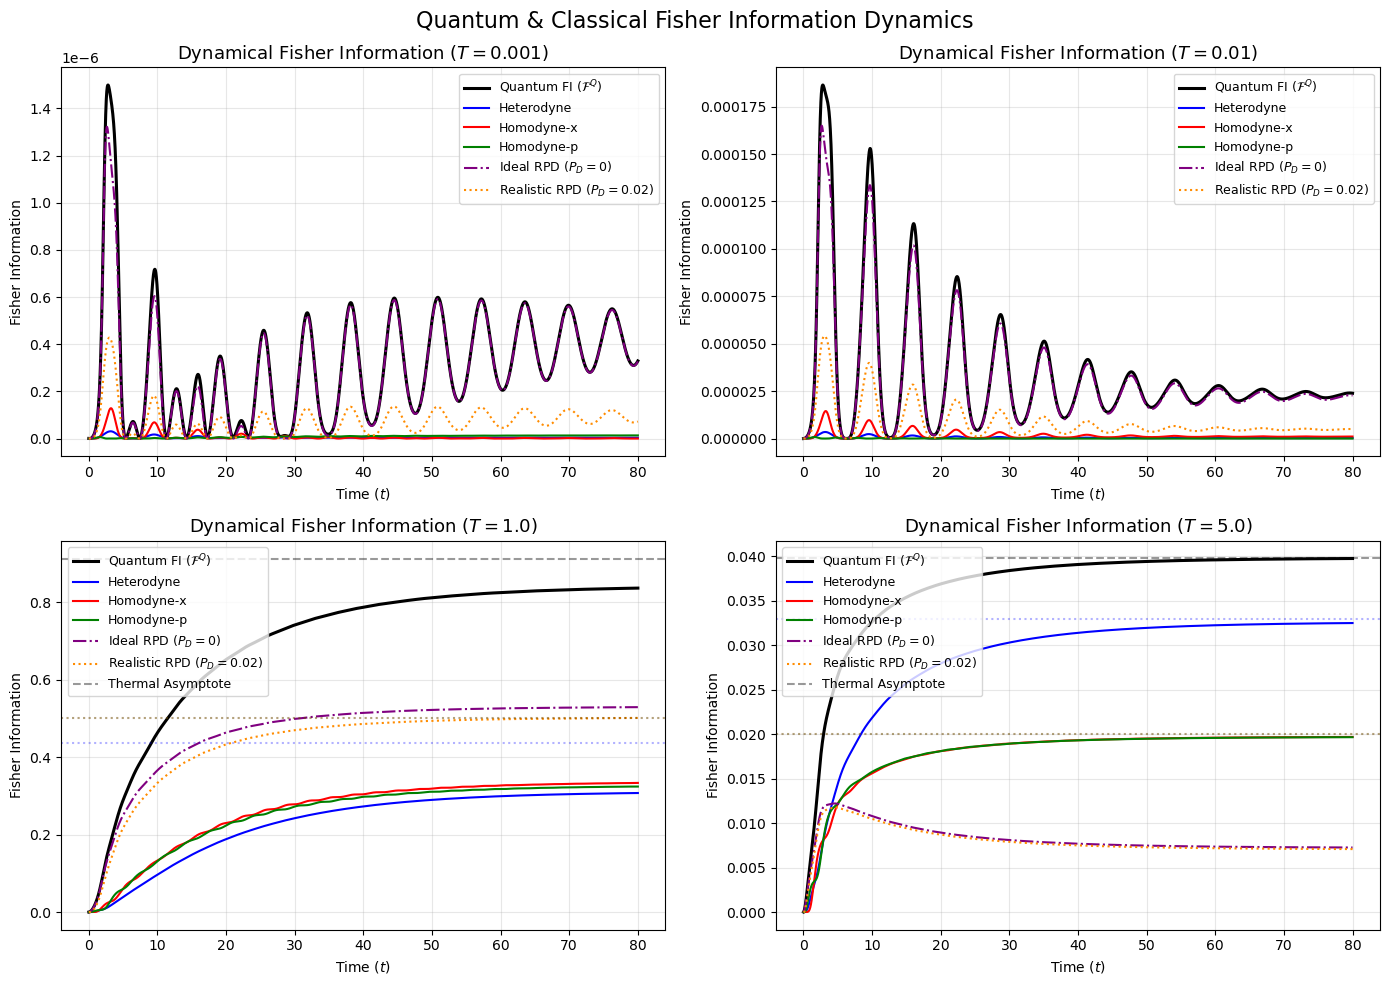

In [6]:
def evolve_all_FI_dynamics(t_array,x0, p0, sigma0, alpha1, alpha2, Temp, gamma, G, Gdot, mass=1.0):
    dt = t_array[1] - t_array[0]
    N = len(t_array)
    
    G_r = G.real
    Gdot_r = Gdot.real
    Gddot_r = Gddot.real
    
    x_mean = Gdot_r * x0 + (G_r / mass) * p0
    p_mean = mass * Gddot_r * x0 + Gdot_r * p0
    # System contribution to Covariance (Constant T-derivative = 0)
    sx0, sp0, sxp0 = sigma0[0, 0], sigma0[1, 1], sigma0[0, 1]
    var_x_sys = (Gdot_r**2) * sx0 + (G_r / mass)**2 * sp0 + 2 * Gdot_r * (G_r / mass) * sxp0
    a, b = mass * Gddot_r, Gdot_r 
    var_p_sys = (a**2) * sx0 + (b**2) * sp0 + 2 * a * b * sxp0
    cov_xp_sys = Gdot_r * a * sx0 + (G_r/mass) * b * sp0 + (Gdot_r * b + (G_r/mass)*a)*sxp0

    # Precompute noise kernel and its Temperature derivative
    nu_grid = np.array([noise_kernel_residue(t, gamma, alpha1, alpha2, Temp) for t in t_array]) / mass
    dnu_grid = dnu_dT_residue(t_array, gamma, alpha1, alpha2, Temp) / mass 

    if not np.all(np.isfinite(nu_grid)):
        raise ValueError("nu_grid contains NaNs or infs")

    if not np.all(np.isfinite(dnu_grid)):
        raise ValueError("dnu_grid contains NaNs or infs")

    # Dark count probability (set to 0.0 for an ideal detector, or e.g., 1e-3 for realistic APDs)
    P_D = 0.0 
    
    # Arrays to store tracking variables (add FI_rpd)
    # Arrays to store tracking variables (added FI_rpd_real)
    FI_het, FI_hom_x, FI_hom_p, QFI, FI_rpd, FI_rpd_real, error = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)
    
    # Define Measurement Matrices
    sig_M_het = np.array([[0.5, 0.0], [0.0, 0.5]])
    sig_M_hom_x = np.array([[1e-6, 0.0], [0.0, 1e6]]) # Infinite noise on p
    sig_M_hom_p = np.array([[1e6, 0.0], [0.0, 1e-6]]) # Infinite noise on x

    # Thermal values for the FI
    FI_th_het = 0.5 * ((1/(Temp+sig_M_het[0,0]*Omega_S)**2)+(1/(Temp+sig_M_het[1,1])**2))
    FI_th_hom_x = 0.5 * ((1/(Temp + sig_M_hom_x[0,0]*Omega_S)**2)+(1/(Temp + sig_M_hom_x[1,1])**2))
    FI_th_hom_p = 0.5 * ((1/(Temp + sig_M_hom_p[0,0]*Omega_S)**2)+(1/(Temp + sig_M_hom_p[1,1])**2))

    # Symplectic Matrix for QFI
    Omega_symp = np.array([[0, 1], [-1, 0]])
    kron_omega = np.kron(Omega_symp, Omega_symp)
    
    def calc_classical_CFI(sig, dsig, sig_M):
        inv_term = np.linalg.inv(sig + sig_M)
        prod = np.dot(inv_term, dsig)
        return 0.5 * np.trace(np.dot(prod, prod))

    for i in tqdm(range(1, N), desc="Simulating Dynamics & FIs"):
        G_slice = G_r[:i+1][::-1] 
        Gd_slice = Gdot_r[:i+1][::-1] 
        nu_seg = nu_grid[:i+1]  
        dnu_seg = dnu_grid[:i+1]
        
        # Integrals (Toeplitz)
        yG = matmul_toeplitz((nu_seg, nu_seg), G_slice)
        yGd = matmul_toeplitz((nu_seg, nu_seg), Gd_slice)
        var_x_bath = np.dot(G_slice, yG) * dt**2
        var_p_bath = np.dot(Gd_slice, yGd) * dt**2
        cov_xp_bath = np.dot(G_slice, yGd) * dt**2
        
        sigma_t = np.array([
            [var_x_sys[i] + var_x_bath, cov_xp_sys[i] + cov_xp_bath],
            [cov_xp_sys[i] + cov_xp_bath, var_p_sys[i] + var_p_bath]
        ])
        
        dyG = matmul_toeplitz((dnu_seg, dnu_seg), G_slice)
        dyGd = matmul_toeplitz((dnu_seg, dnu_seg), Gd_slice)
        dvar_x_bath = np.dot(G_slice, dyG) * dt**2
        dvar_p_bath = np.dot(Gd_slice, dyGd) * dt**2
        dcov_xp_bath = np.dot(G_slice, dyGd) * dt**2
        
        dsigma_t = np.array([
            [dvar_x_bath, dcov_xp_bath],
            [dcov_xp_bath, dvar_p_bath]
        ])
        
        # 1. Classical FIs
        FI_het[i] = (calc_classical_CFI(sigma_t, dsigma_t, sig_M_het))
        FI_hom_x[i] = (calc_classical_CFI(sigma_t, dsigma_t, sig_M_hom_x))
        FI_hom_p[i] = (calc_classical_CFI(sigma_t, dsigma_t, sig_M_hom_p))
        
        # --- On/Off Photodetection (RPD) FI ---
        A_rpd = sigma_t + sig_M_het
        det_A = np.linalg.det(A_rpd)
        inv_A = np.linalg.inv(A_rpd)
        trace_term = np.trace(np.dot(inv_A, dsigma_t))
        
        # Base vacuum probability without dark counts
        P_0_base = 1.0 / np.sqrt(det_A)
        
        # 1. Ideal RPD (P_D = 0.0)
        dP_0_ideal = -0.5 * P_0_base * trace_term
        FI_rpd[i] = (dP_0_ideal**2) / (P_0_base * (1.0 - P_0_base) + 1e-15)
        
        # 2. Realistic RPD (P_D = 0.02)
        P_D_val = 0.02
        P_0_real = (1.0 - P_D_val) * P_0_base
        dP_0_real = -0.5 * P_0_real * trace_term
        FI_rpd_real[i] = (dP_0_real**2) / (P_0_real * (1.0 - P_0_real) + 1e-15)
        
        # 2. Quantum FI (Exact Bures metric formula) - FIXED
        if not np.all(np.isfinite(sigma_t)):
            raise ValueError(
                f"sigma_t contains NaNs at time index {i}, t={t_array[i]}"
            )
        kron_sigma = np.kron(sigma_t, sigma_t)
        M = kron_sigma - 0.25*kron_omega

        if not np.all(np.isfinite(M)):
            raise ValueError("Matrix M contains NaNs.")

        evals, evecs = np.linalg.eigh(M)
        threshold = 1e-7
        evals_inv = np.where(evals > threshold, 1.0 / evals, 0.0)
        M_inv = evecs @ np.diag(evals_inv) @ evecs.T
        
        dsigma_vec = dsigma_t.flatten(order='F') 
        QFI[i] = (0.5 * np.dot(dsigma_vec.T, np.dot(M_inv, dsigma_vec)))
        
    return {
        "time": t_array, 
        "FI_het": FI_het, 
        "FI_hom_x": FI_hom_x, 
        "FI_hom_p": FI_hom_p, 
        "FI_rpd": FI_rpd,
        "FI_rpd_real": FI_rpd_real,  # <-- Add this line
        "QFI": QFI, 
        "FI_th_het": FI_th_het, 
        "FI_th_hom_x": FI_th_hom_x, 
        "FI_th_hom_p": FI_th_hom_p,
    }


# ==========================================
# 4. EXECUTION BLOCK
# ==========================================
if __name__ == "__main__":
    # --- Physical Parameters ---
    gamma = 1.0
    alpha1 = 0.1
    alpha2 = 3.0
    Omega_S_bare = 1.0
    delta_Omega_s = np.sqrt(alpha1)
    Omega_S = np.sqrt(Omega_S_bare**2 + delta_Omega_s**2)
    mass = 1.0
    
    # Simulation Time Grid
    times = np.linspace(0, 80, 4500)
    
    # Laplace Polynomials for Green's Function
    B = [1, gamma, alpha2 * gamma]
    A = [1, gamma, alpha2 * gamma + Omega_S**2, gamma * Omega_S**2, alpha2 * gamma * Omega_S**2 - gamma * alpha1 * alpha2]
    
    # Extract Green's Function
    info = inverse_laplace_rational(B, A)
    G, Gprime_of_t, Gddot = derivatives_from_residues(times, info["residues"], info["poles"])
    Gdot = Gprime_of_t
    
    # Initial State Covariance Matrix (Fixed grouping bug)
    x0 = 0.0
    p0 = 0.0
    sigma0 = np.array([[1.0 / (2.0 * Omega_S_bare), 0.0], 
                       [0.0, Omega_S_bare / 2.0]])

    # List of temperatures to plot
    temperatures = [1e-3, 1e-2, 1.0, 5.0]
    
    # --- Setup 2x2 Subplot Grid ---
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()  # Flatten 2D array to 1D for easy iteration
    
    for ax, temp in zip(axes, temperatures):
        print(f"\nSimulating Dynamics & FIs for T = {temp}...")
        
        # Thermal QFI for a single HO
        QFI_th_HO = 0.25 * (Omega_S**2 / temp**4) * csch2(Omega_S / (2.0 * temp))
        
        # 1. Run Dynamic Simulation
        sol = evolve_all_FI_dynamics(times, x0, p0, sigma0, alpha1, alpha2, temp, gamma, G, Gdot, mass)
        
        # 2. Plot Dynamical Curves
        ax.plot(sol["time"][1:], sol["QFI"][1:], color='black', linewidth=2.2, label=r"Quantum FI ($\mathcal{F}^Q$)")
        ax.plot(sol["time"][1:], sol["FI_het"][1:], color='blue', linewidth=1.5, label="Heterodyne")
        ax.plot(sol["time"][1:], sol["FI_hom_x"][1:], color='red', linewidth=1.5, label="Homodyne-x")
        ax.plot(sol["time"][1:], sol["FI_hom_p"][1:], color='green', linewidth=1.5, label="Homodyne-p")
        ax.plot(sol["time"][1:], sol["FI_rpd"][1:], color='purple', linewidth=1.5, linestyle='-.', label="Ideal RPD ($P_D=0$)")
        ax.plot(sol["time"][1:], sol["FI_rpd_real"][1:], color='darkorange', linewidth=1.5, linestyle=':', label="Realistic RPD ($P_D=0.02$)")
        
        # 3. Plot Thermal Asymptotes (only meaningful to display at moderate/high T)
        if temp >= 1.0:
            ax.axhline(QFI_th_HO, color='black', linestyle='--', alpha=0.4, label="Thermal Asymptote")
            ax.axhline(sol["FI_th_hom_x"], linestyle=':', alpha=0.3, color='red')
            ax.axhline(sol["FI_th_hom_p"], linestyle=':', alpha=0.3, color='green')
            ax.axhline(sol["FI_th_het"], linestyle=':', alpha=0.3, color='blue')
        
        # 4. Subplot Formatting
        ax.set_title(rf"Dynamical Fisher Information ($T = {temp}$)", fontsize=13)
        ax.set_xlabel("Time ($t$)")
        ax.set_ylabel("Fisher Information")
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=9)
        
        # Optional: Uncomment if you want log-scale on y for ultra-low temperatures
        # if temp < 0.1:
        #     ax.set_yscale('log')

    # Overall Figure Formatting
    plt.suptitle("Quantum & Classical Fisher Information Dynamics", fontsize=16, y=0.98)
    plt.tight_layout()
    plt.show()

# Fisher Rates

Simulating Dynamics & FIs: 100%|██████████| 11999/11999 [02:45<00:00, 72.61it/s]


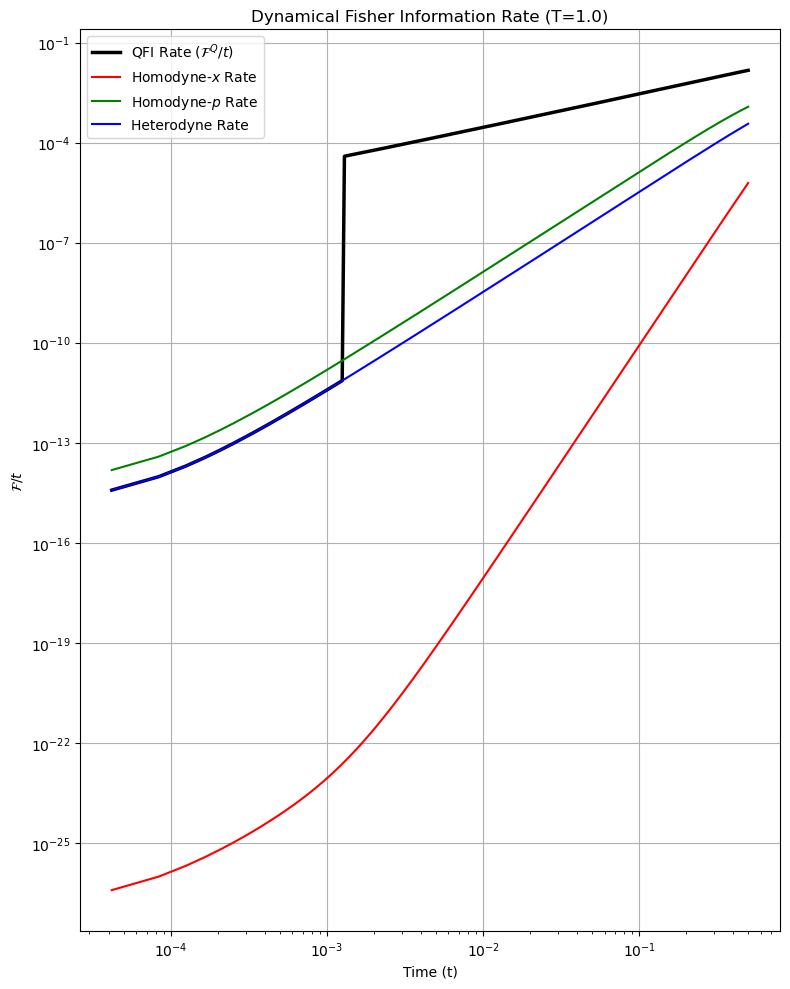

In [5]:
def evolve_all_FI_dynamics(t_array,x0, p0, sigma0, alpha1, alpha2, Temp, gamma, G, Gdot, Gddot, mass=1.0):
    dt = t_array[1] - t_array[0]
    N = len(t_array)
    
    G_r = G.real
    Gdot_r = Gdot.real
    Gddot_r = Gddot.real
    
    x_mean = Gdot_r * x0 + (G_r / mass) * p0
    p_mean = mass * Gddot_r * x0 + Gdot_r * p0
    # System contribution to Covariance (Constant T-derivative = 0)
    sx0, sp0, sxp0 = sigma0[0, 0], sigma0[1, 1], sigma0[0, 1]
    var_x_sys = (Gdot_r**2) * sx0 + (G_r / mass)**2 * sp0 + 2 * Gdot_r * (G_r / mass) * sxp0
    a, b = mass * Gddot_r, Gdot_r 
    var_p_sys = (a**2) * sx0 + (b**2) * sp0 + 2 * a * b * sxp0
    cov_xp_sys = Gdot_r * a * sx0 + (G_r/mass) * b * sp0 + (Gdot_r * b + (G_r/mass)*a)*sxp0

    # Precompute noise kernel and its Temperature derivative
    nu_grid = np.array([noise_kernel_residue(t, gamma, alpha1, alpha2, Temp) for t in t_array]) / mass
    dnu_grid = dnu_dT_residue(t_array, gamma, alpha1, alpha2, Temp) / mass 

    # Arrays to store tracking variables (Value and Rate)
    FI_het, FI_hom_x, FI_hom_p, QFI = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)
    rate_het, rate_hom_x, rate_hom_p, rate_QFI = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)
    
    # Define Measurement Matrices
    sig_M_het = np.array([[0.5, 0.0], [0.0, 0.5]])
    sig_M_hom_x = np.array([[1e-6, 0.0], [0.0, 1e6]]) # Infinite noise on p
    sig_M_hom_p = np.array([[1e6, 0.0], [0.0, 1e-6]]) # Infinite noise on x

    # Symplectic Matrix for QFI
    Omega_symp = np.array([[0, 1], [-1, 0]])
    kron_omega = np.kron(Omega_symp, Omega_symp)
    
    def calc_classical_CFI(sig, dsig, sig_M):
        inv_term = np.linalg.inv(sig + sig_M)
        prod = np.dot(inv_term, dsig)
        return 0.5 * np.trace(np.dot(prod, prod))

    for i in tqdm(range(1, N), desc="Simulating Dynamics & FIs"):
        G_slice = G_r[:i+1][::-1] 
        Gd_slice = Gdot_r[:i+1][::-1] 
        nu_seg = nu_grid[:i+1]  
        dnu_seg = dnu_grid[:i+1]
        
        # Integrals (Toeplitz)
        yG = matmul_toeplitz((nu_seg, nu_seg), G_slice)
        yGd = matmul_toeplitz((nu_seg, nu_seg), Gd_slice)
        var_x_bath = np.dot(G_slice, yG) * dt**2
        var_p_bath = np.dot(Gd_slice, yGd) * dt**2
        cov_xp_bath = np.dot(G_slice, yGd) * dt**2
        
        sigma_t = np.array([
            [var_x_sys[i] + var_x_bath, cov_xp_sys[i] + cov_xp_bath],
            [cov_xp_sys[i] + cov_xp_bath, var_p_sys[i] + var_p_bath]
        ])
        
        dyG = matmul_toeplitz((dnu_seg, dnu_seg), G_slice)
        dyGd = matmul_toeplitz((dnu_seg, dnu_seg), Gd_slice)
        dvar_x_bath = np.dot(G_slice, dyG) * dt**2
        dvar_p_bath = np.dot(Gd_slice, dyGd) * dt**2
        dcov_xp_bath = np.dot(G_slice, dyGd) * dt**2
        
        dsigma_t = np.array([
            [dvar_x_bath, dcov_xp_bath],
            [dcov_xp_bath, dvar_p_bath]
        ])
        
        # 1. Classical FIs
        FI_het[i] = calc_classical_CFI(sigma_t, dsigma_t, sig_M_het)
        FI_hom_x[i] = calc_classical_CFI(sigma_t, dsigma_t, sig_M_hom_x)
        FI_hom_p[i] = calc_classical_CFI(sigma_t, dsigma_t, sig_M_hom_p)
        
        # 2. Quantum FI
        kron_sigma = np.kron(sigma_t, sigma_t)
        M = kron_sigma - 0.25 * kron_omega
        
        # pinvh is highly optimized for symmetric/Hermitian matrices
        M_inv = sla.pinvh(M, atol=1e-7)
        
        dsigma_vec = dsigma_t.flatten(order='F') 
        QFI[i] = 0.5 * np.dot(dsigma_vec.T, np.dot(M_inv, dsigma_vec))
        
        # 3. Calculate Rates directly
        t_current = t_array[i]
        rate_het[i] = FI_het[i] / t_current
        rate_hom_x[i] = FI_hom_x[i] / t_current
        rate_hom_p[i] = FI_hom_p[i] / t_current
        rate_QFI[i] = QFI[i] / t_current
        
    return {
        "time": t_array, 
        "FI_het": FI_het, "FI_hom_x": FI_hom_x, "FI_hom_p": FI_hom_p, "QFI": QFI,
        "rate_het": rate_het, "rate_hom_x": rate_hom_x, "rate_hom_p": rate_hom_p, "rate_QFI": rate_QFI
    }

# ==========================================
# 4. EXECUTION BLOCK & RATE PLOTTING
# ==========================================
if __name__ == "__main__":
    # --- Physical Parameters ---
    gamma = 1
    alpha1 = 0.1
    alpha2 = 2.0
    Omega_S_bare = 1.0
    delta_Omega_s = np.sqrt(alpha1)
    Omega_S = np.sqrt(Omega_S_bare**2 + delta_Omega_s**2)
    temp = 1.0
    mass = 1.0
    
    # Simulation Time Grid
    times = np.linspace(0, 0.5, 12000)
    
    # Laplace Polynomials for Green's Function
    B = [1, gamma, alpha2 * gamma]
    A = [1, gamma, alpha2 * gamma + Omega_S**2, gamma * Omega_S**2, alpha2 * gamma * Omega_S**2 - gamma * alpha1 * alpha2]
    
    # Extract Green's Function
    info = inverse_laplace_rational(B, A)
    G, Gprime_of_t, Gddot = derivatives_from_residues(times, info["residues"], info["poles"])

    Gdot = Gprime_of_t
    
    # Initial State Covariance Matrix 
    x0 = 0.0
    p0 = 0.0
    sigma0 = np.array([[1.0 / 2*Omega_S_bare, 0], 
                       [0, Omega_S_bare / 2.0]])

    # --- 1. Run Dynamic Simulation ---
    sol = evolve_all_FI_dynamics(times, x0, p0, sigma0, alpha1, alpha2, temp, gamma, G, Gdot, Gddot, mass)
    
    # --- 2. Extract Data (Slicing [1:] to drop t=0) ---
    valid_times = sol["time"][1:]
    
    QFI_rate = sol["rate_QFI"][1:]
    FI_hom_x_rate = sol["rate_hom_x"][1:]
    FI_hom_p_rate = sol["rate_hom_p"][1:]
    FI_het_rate = sol["rate_het"][1:]

    # --- 3. Plot Results ---
    plt.figure(figsize=(8, 10))
    
    # Dynamical Rate Curves
    plt.plot(valid_times, QFI_rate, color='black', linewidth=2.5, label=r"QFI Rate ($\mathcal{F}^Q / t$)")
    plt.plot(valid_times, FI_hom_x_rate, color='red', linewidth=1.5, label=r"Homodyne-$x$ Rate")
    plt.plot(valid_times, FI_hom_p_rate, color='green', linewidth=1.5, label=r"Homodyne-$p$ Rate")
    plt.plot(valid_times, FI_het_rate, color='blue', linewidth=1.5, label=r"Heterodyne Rate")
    
    plt.xlabel("Time (t)")
    plt.ylabel(r"$\mathcal{F} / t$")
    
    plt.yscale('log')
    plt.xscale('log')
    #plt.ylim(10e-15, 0.1)
    
    plt.title(rf"Dynamical Fisher Information Rate (T={temp})")
    plt.legend(loc='best')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Fisher Rate for Squeezing

Sweeping Squeezing Parameters (T=0.01)...
  -> Simulating r = 0.01


Simulating Dynamics & FIs: 100%|██████████| 4999/4999 [00:41<00:00, 119.75it/s]


  -> Simulating r = 0.1


Simulating Dynamics & FIs: 100%|██████████| 4999/4999 [00:37<00:00, 131.80it/s]


  -> Simulating r = 1.0


Simulating Dynamics & FIs: 100%|██████████| 4999/4999 [00:29<00:00, 170.37it/s]


  -> Simulating r = 10.0


Simulating Dynamics & FIs: 100%|██████████| 4999/4999 [00:19<00:00, 251.85it/s]


  -> Simulating r = 100.0


Simulating Dynamics & FIs: 100%|██████████| 4999/4999 [00:20<00:00, 245.78it/s]


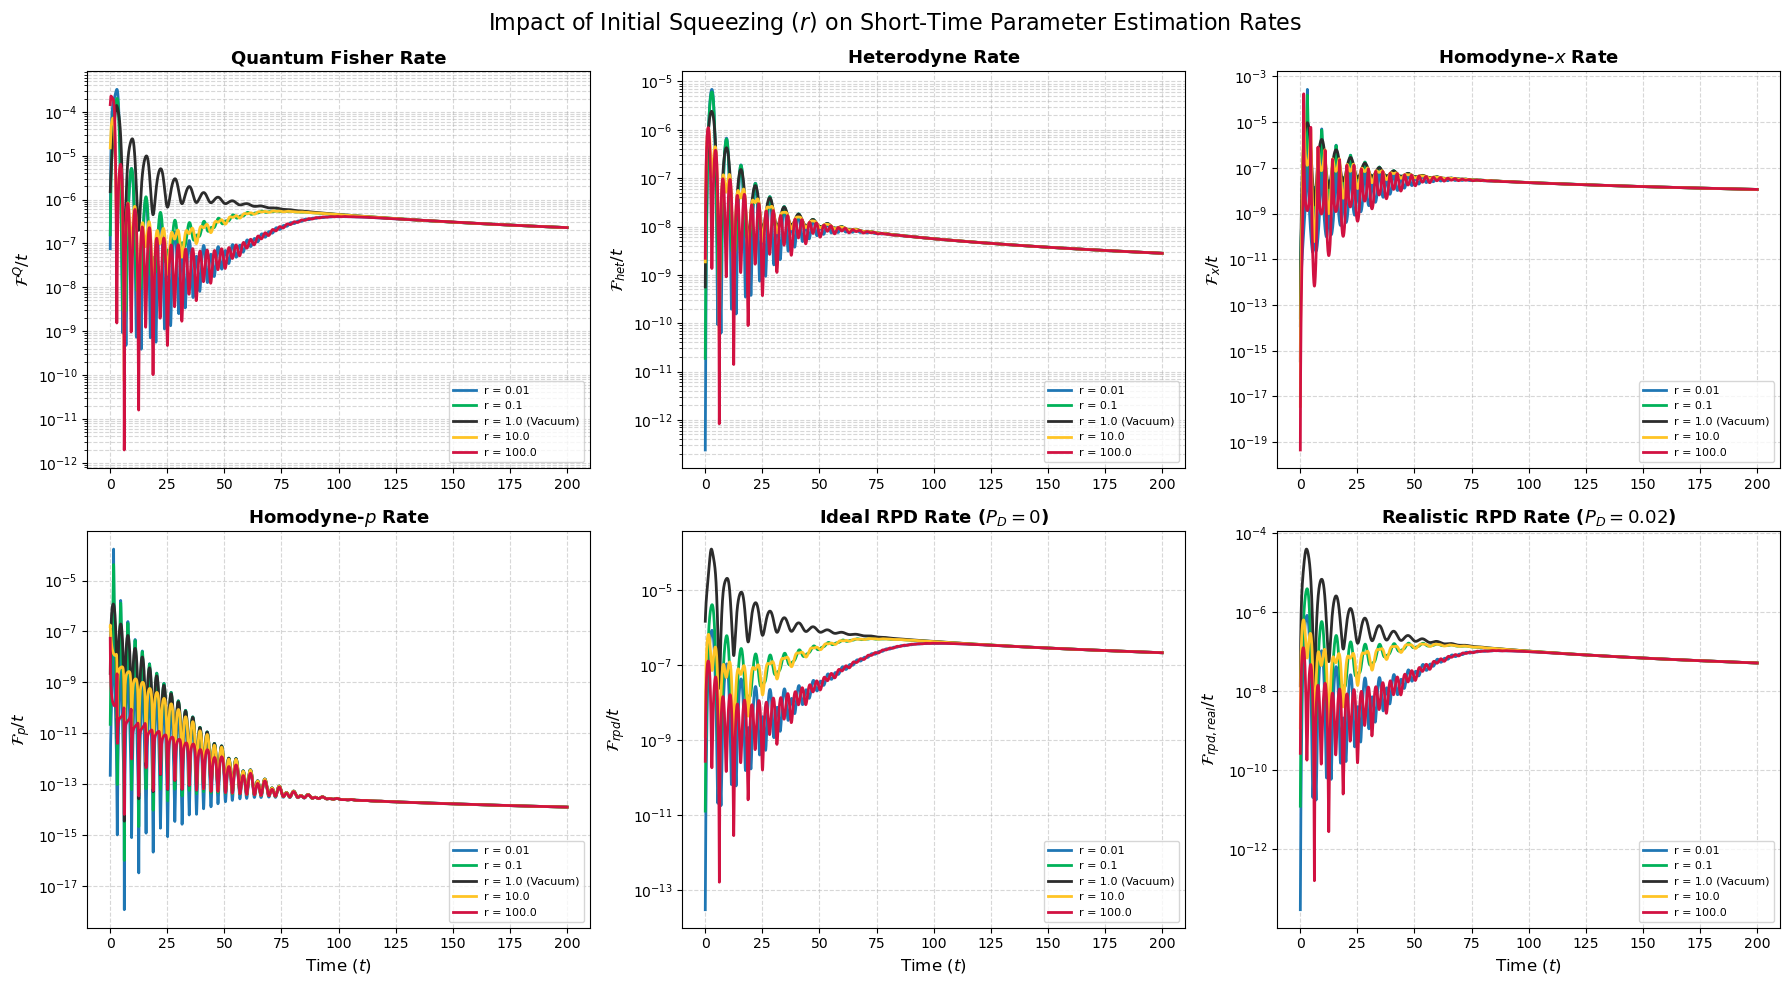

In [6]:
def evolve_all_FI_dynamics(t_array, x0, p0, sigma0, alpha1, alpha2, Temp, gamma, G, Gdot, Gddot, mass=1.0):
    dt = t_array[1] - t_array[0]
    N = len(t_array)
    
    G_r = G.real
    Gdot_r = Gdot.real
    Gddot_r = Gddot.real
    
    # System contribution to Covariance
    sx0, sp0, sxp0 = sigma0[0, 0], sigma0[1, 1], sigma0[0, 1]
    var_x_sys = (Gdot_r**2) * sx0 + (G_r / mass)**2 * sp0 + 2 * Gdot_r * (G_r / mass) * sxp0
    a, b = mass * Gddot_r, Gdot_r 
    var_p_sys = (a**2) * sx0 + (b**2) * sp0 + 2 * a * b * sxp0
    cov_xp_sys = Gdot_r * a * sx0 + (G_r/mass) * b * sp0 + (Gdot_r * b + (G_r/mass)*a)*sxp0

    # Precompute noise kernel and its Temperature derivative
    nu_grid = np.array([noise_kernel_residue(t, gamma, alpha1, alpha2, Temp) for t in t_array]) / mass
    dnu_grid = dnu_dT_residue(t_array, gamma, alpha1, alpha2, Temp) / mass 

    # Arrays to store tracking variables (Values and Rates)
    FI_het, FI_hom_x, FI_hom_p, QFI = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)
    FI_rpd_ideal, FI_rpd_real = np.zeros(N), np.zeros(N)
    
    rate_het, rate_hom_x, rate_hom_p, rate_QFI = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)
    rate_rpd_ideal, rate_rpd_real = np.zeros(N), np.zeros(N)
    
    # Define Measurement Matrices
    sig_M_het = np.array([[0.5, 0.0], [0.0, 0.5]])
    sig_M_hom_x = np.array([[1e-6, 0.0], [0.0, 1e6]])
    sig_M_hom_p = np.array([[1e6, 0.0], [0.0, 1e-6]])

    # Symplectic Matrix for QFI
    Omega_symp = np.array([[0, 1], [-1, 0]])
    kron_omega = np.kron(Omega_symp, Omega_symp)
    
    def calc_classical_CFI(sig, dsig, sig_M):
        inv_term = np.linalg.inv(sig + sig_M)
        prod = np.dot(inv_term, dsig)
        return 0.5 * np.trace(np.dot(prod, prod))

    for i in tqdm(range(1, N), desc="Simulating Dynamics & FIs"):
        G_slice = G_r[:i+1][::-1] 
        Gd_slice = Gdot_r[:i+1][::-1] 
        nu_seg = nu_grid[:i+1]  
        dnu_seg = dnu_grid[:i+1]
        
        # Integrals (Toeplitz)
        yG = matmul_toeplitz((nu_seg, nu_seg), G_slice)
        yGd = matmul_toeplitz((nu_seg, nu_seg), Gd_slice)
        var_x_bath = np.dot(G_slice, yG) * dt**2
        var_p_bath = np.dot(Gd_slice, yGd) * dt**2
        cov_xp_bath = np.dot(G_slice, yGd) * dt**2
        
        sigma_t = np.array([
            [var_x_sys[i] + var_x_bath, cov_xp_sys[i] + cov_xp_bath],
            [cov_xp_sys[i] + cov_xp_bath, var_p_sys[i] + var_p_bath]
        ])
        
        dyG = matmul_toeplitz((dnu_seg, dnu_seg), G_slice)
        dyGd = matmul_toeplitz((dnu_seg, dnu_seg), Gd_slice)
        dvar_x_bath = np.dot(G_slice, dyG) * dt**2
        dvar_p_bath = np.dot(Gd_slice, dyGd) * dt**2
        dcov_xp_bath = np.dot(G_slice, dyGd) * dt**2
        
        dsigma_t = np.array([
            [dvar_x_bath, dcov_xp_bath],
            [dcov_xp_bath, dvar_p_bath]
        ])
        
        # 1. Classical FIs
        FI_het[i] = calc_classical_CFI(sigma_t, dsigma_t, sig_M_het)
        FI_hom_x[i] = calc_classical_CFI(sigma_t, dsigma_t, sig_M_hom_x)
        FI_hom_p[i] = calc_classical_CFI(sigma_t, dsigma_t, sig_M_hom_p)
        
        # --- 2. Photodetection FIs (Ideal & Realistic) ---
        A_rpd = sigma_t + sig_M_het
        det_A = np.linalg.det(A_rpd)
        inv_A = np.linalg.inv(A_rpd)
        trace_term = np.trace(np.dot(inv_A, dsigma_t))
        
        P_0_base = 1.0 / np.sqrt(det_A)
        
        # Ideal RPD (P_D = 0)
        dP_0_ideal = -0.5 * P_0_base * trace_term
        FI_rpd_ideal[i] = (dP_0_ideal**2) / (P_0_base * (1.0 - P_0_base) + 1e-15)
        
        # Realistic RPD (P_D = 0.02)
        P_0_real = (1.0 - 0.02) * P_0_base
        dP_0_real = -0.5 * P_0_real * trace_term
        FI_rpd_real[i] = (dP_0_real**2) / (P_0_real * (1.0 - P_0_real) + 1e-15)

        # 3. Quantum FI
        kron_sigma = np.kron(sigma_t, sigma_t)
        M = kron_sigma - 0.25*kron_omega
        evals, evecs = np.linalg.eigh(M)
        threshold = 1e-12
        evals_inv = np.where(evals > threshold, 1.0 / evals, 0.0)
        M_inv = evecs @ np.diag(evals_inv) @ evecs.T
        
        dsigma_vec = dsigma_t.flatten(order='F') 
        QFI[i] = 0.5 * np.dot(dsigma_vec.T, np.dot(M_inv, dsigma_vec))
        
        # 4. Calculate Rates directly
        t_current = t_array[i]
        rate_het[i] = FI_het[i] / t_current
        rate_hom_x[i] = FI_hom_x[i] / t_current
        rate_hom_p[i] = FI_hom_p[i] / t_current
        rate_rpd_ideal[i] = FI_rpd_ideal[i] / t_current
        rate_rpd_real[i] = FI_rpd_real[i] / t_current
        rate_QFI[i] = QFI[i] / t_current
        
    return {
        "time": t_array, 
        "rate_het": rate_het, "rate_hom_x": rate_hom_x, "rate_hom_p": rate_hom_p, 
        "rate_rpd_ideal": rate_rpd_ideal, "rate_rpd_real": rate_rpd_real, "rate_QFI": rate_QFI
    }

# ==========================================
# 4. EXECUTION BLOCK (2x3 GRID)
# ==========================================
if __name__ == "__main__":
    gamma = 1.0
    alpha1 = 0.1
    alpha2 = 2.0
    Omega_S_bare = 1.0
    delta_Omega_s = np.sqrt(alpha1)
    Omega_S = np.sqrt(Omega_S_bare**2 + delta_Omega_s**2)
    temp = 1e-2
    mass = 1.0
    
    # Short time grid focused on transient rates
    times = np.linspace(0, 200, 5000)
    
    B = [1, gamma, alpha2 * gamma]
    A = [1, gamma, alpha2 * gamma + Omega_S**2, gamma * Omega_S**2, alpha2 * gamma * Omega_S**2 - gamma * alpha1 * alpha2]
    
    info = inverse_laplace_rational(B, A)
    G, Gprime_of_t, Gddot = derivatives_from_residues(times, info["residues"], info["poles"])
    Gdot = Gprime_of_t
    
    x0, p0 = 0.0, 0.0
    r_values = [0.01, 0.1, 1.0, 10.0, 100.0]
    colors = ['#1f77b4', '#00b159', '#2c2c2c', '#ffc425', '#d11141'] 

    # --- Use a 2x3 Grid to cleanly display all 6 rates ---
    fig, axs = plt.subplots(2, 3, figsize=(18, 10))
    ax_qfi, ax_het, ax_homx = axs[0, 0], axs[0, 1], axs[0, 2]
    ax_homp, ax_rpdi, ax_rpdr = axs[1, 0], axs[1, 1], axs[1, 2]

    print(f"Sweeping Squeezing Parameters (T={temp})...")
    
    for r, color in zip(r_values, colors):
        print(f"  -> Simulating r = {r}")
        sigma0 = 0.5 * np.array([[r, 0], [0, 1.0/r]])

        sol = evolve_all_FI_dynamics(times, x0, p0, sigma0, alpha1, alpha2, temp, gamma, G, Gdot, Gddot, mass)
        
        valid_times = sol["time"][1:]
        label_str = f"r = {r}" if r != 1.0 else "r = 1.0 (Vacuum)"
        
        # Plot individual rates across subplots
        ax_qfi.plot(valid_times, sol["rate_QFI"][1:], color=color, linewidth=2, label=label_str)
        ax_het.plot(valid_times, sol["rate_het"][1:], color=color, linewidth=2, label=label_str)
        ax_homx.plot(valid_times, sol["rate_hom_x"][1:], color=color, linewidth=2, label=label_str)
        ax_homp.plot(valid_times, sol["rate_hom_p"][1:], color=color, linewidth=2, label=label_str)
        ax_rpdi.plot(valid_times, sol["rate_rpd_ideal"][1:], color=color, linewidth=2, label=label_str)
        ax_rpdr.plot(valid_times, sol["rate_rpd_real"][1:], color=color, linewidth=2, label=label_str)

    # --- Formatting all 6 Subplots ---
    axes = [ax_qfi, ax_het, ax_homx, ax_homp, ax_rpdi, ax_rpdr]
    titles = [
        "Quantum Fisher Rate", "Heterodyne Rate", "Homodyne-$x$ Rate", 
        "Homodyne-$p$ Rate", "Ideal RPD Rate ($P_D=0$)", "Realistic RPD Rate ($P_D=0.02$)"
    ]
    ylabels = [
        r"$\mathcal{F}^Q / t$", r"$\mathcal{F}_{het} / t$", r"$\mathcal{F}_{x} / t$", 
        r"$\mathcal{F}_{p} / t$", r"$\mathcal{F}_{rpd} / t$", r"$\mathcal{F}_{rpd, real} / t$"
    ]

    for ax, title, ylabel in zip(axes, titles, ylabels):
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.set_ylabel(ylabel, fontsize=12)
        ax.set_yscale('log')
        ax.grid(True, which="both", ls="--", alpha=0.5)
        ax.legend(loc='lower right', fontsize=8)
        
        if ax in [ax_homp, ax_rpdi, ax_rpdr]:
            ax.set_xlabel("Time ($t$)", fontsize=12)

    plt.suptitle("Impact of Initial Squeezing ($r$) on Short-Time Parameter Estimation Rates", fontsize=16, y=0.98)
    plt.tight_layout()
    plt.show()

# Short-Time Limit

Simulating Dynamics & FIs: 100%|██████████| 1999/1999 [00:11<00:00, 179.26it/s]


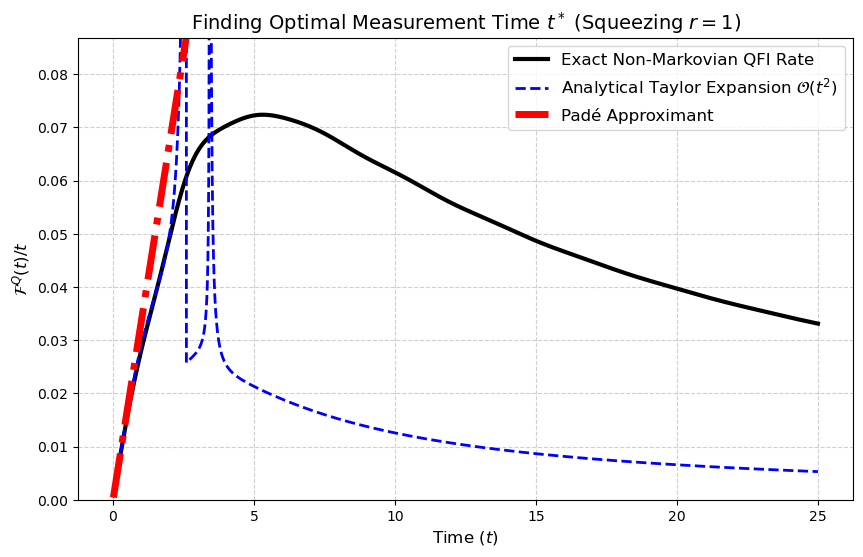

In [18]:

def spectral_density(w, gamma, alpha1, alpha2):
    """Lorentzian spectral density."""
    return (gamma**2 * alpha1 * alpha2 * w) / ((gamma * w)**2 + (alpha2 * gamma - w**2)**2)

def calc_analytic_nu_terms(gamma, alpha1, alpha2, Temp):
    beta = 1.0 / Temp
    
    # Integrand for nu(0)
    def integrand_nu(w):
        val = (1.0 / np.pi) * spectral_density(w, gamma, alpha1, alpha2) * coth(beta * w / 2.0)
        return float(np.real(val))
    
    # Integrand for dnu/dT(0)
    def integrand_dnu_dT(w):
        val = (1.0 / np.pi) * spectral_density(w, gamma, alpha1, alpha2) * (w / (2.0 * Temp**2)) * csch2(beta * w / 2.0)
        return float(np.real(val))
    
    # quad handles the infinite upper limit natively
    nu_0, _ = integrate.quad(integrand_nu, 1e-8, np.inf, limit=200)
    dnu_dT_0, _ = integrate.quad(integrand_dnu_dT, 1e-8, np.inf, limit=200)
    
    return nu_0, dnu_dT_0

def get_analytic_QFI_rate(t_array, r, Omega_S, nu_0, dnu_dT_0):
    """
    Constructs the O(t^2) covariance matrix and its Temperature derivative,
    then computes the resulting analytical QFI rate (F/t).
    """
    a0 = 0.5 * r
    b0 = 0.5 * (1.0 / r)
    c0 = 0.0 # Assuming no initial correlations for simplicity
    
    # From the derived r parameter in your text: r_param = b0 - Omega_S^2 * a0
    r_param = b0 - (Omega_S**2) * a0 
    
    rate_QFI_analytic = np.zeros_like(t_array)
    
    for i, t in enumerate(t_array):
        if t == 0:
            continue
            
        # O(t^2) Covariance Matrix
        sig_11 = a0 + c0*t + r_param*(t**2)
        sig_12 = 0.5*c0 + r_param*t - c0*(Omega_S**2)*(t**2)
        sig_22 = b0 - c0*(Omega_S**2)*t + (nu_0 - (Omega_S**2)*r_param)*(t**2)
        
        sigma_t = np.array([[sig_11, sig_12], [sig_12, sig_22]])
        
        # O(t^2) Derivative Matrix (strictly in momentum variance at leading order)
        dsigma_t = np.array([[0, 0], [0, dnu_dT_0 * (t**2)]])
        
        # QFI Computation (same Symplectic structure as exact)
        Omega_symp = np.array([[0, 1], [-1, 0]])
        kron_omega = np.kron(Omega_symp, Omega_symp)
        kron_sigma = np.kron(sigma_t, sigma_t)
        M = kron_sigma - 0.25 * kron_omega
        
        evals, evecs = np.linalg.eigh(M)
        evals_inv = np.where(evals > 1e-12, 1.0 / evals, 0.0)
        M_inv = evecs @ np.diag(evals_inv) @ evecs.T
        
        dsigma_vec = dsigma_t.flatten(order='F') 
        qfi_val = 0.5 * np.dot(dsigma_vec.T, np.dot(M_inv, dsigma_vec))
        
        rate_QFI_analytic[i] = qfi_val / t
        
    return rate_QFI_analytic

# ==========================================
# 6. EXECUTION & PADÉ COMPARISON
# ==========================================
if __name__ == "__main__":
    # --- Parameters ---
    gamma = 1.0
    alpha1 = 0.1
    alpha2 = 2.0
    Omega_S_bare = 1.0
    delta_Omega_s = np.sqrt(alpha1)
    Omega_S = np.sqrt(Omega_S_bare**2 + delta_Omega_s**2)
    temp = 1
    mass = 1.0
    
    # We focus on the squeezed case (r=0.1) where t* is around 0.1s
    r_test = 1  
    
    # Time grid
    times = np.linspace(0, 25, 2000)
    
    # 1. Exact Dynamics
    B = [1, gamma, alpha2 * gamma]
    A = [1, gamma, alpha2 * gamma + Omega_S**2, gamma * Omega_S**2, alpha2 * gamma * Omega_S**2 - gamma * alpha1 * alpha2]
    info = inverse_laplace_rational(B, A)
    G, Gdot, Gddot = derivatives_from_residues(times, info["residues"], info["poles"])
    
    sigma0 = 0.5 * np.array([[r_test, 0], [0, 1.0/r_test]])
    exact_sol = evolve_all_FI_dynamics(times, 0.0, 0.0, sigma0, alpha1, alpha2, temp, gamma, G, Gdot, Gddot, mass)
    exact_rate = exact_sol["rate_QFI"]
    
    # 2. Analytical O(t^2) Dynamics
    nu_0, dnu_dT_0 = calc_analytic_nu_terms(gamma, alpha1, alpha2, temp)
    analytic_rate = get_analytic_QFI_rate(times, r_test, Omega_S, nu_0, dnu_dT_0)
    
    # 3. Generating the Padé Approximant
    # To do this, we extract the Taylor coefficients of the analytic rate at t=0
    # For a mixed state (r != 1), F/t starts as c_3 * t^3. 
    # We use numpy polyfit on the shortest times to grab these coefficients automatically.
    fit_idx = 10 
    taylor_coeffs = np.polyfit(times[1:fit_idx], analytic_rate[1:fit_idx], deg=3)
    
    # Reverse coefficients for scipy's Pade (it expects lowest order first: c0 + c1*t + ...)
    taylor_coeffs_reversed = taylor_coeffs[::-1]
    
    # Create Padé approximant [M/N]. For a cubic polynomial, a [1/2] or [2/1] Padé works beautifully.
    p, q = pade(taylor_coeffs_reversed, 1) # Denominator degree 1
    
    pade_rate = np.zeros_like(times)
    for i, t in enumerate(times):
        if q(t) != 0:
            pade_rate[i] = p(t) / q(t)
            
    # --- Plotting ---
    plt.figure(figsize=(10, 6))
    plt.plot(times[1:], exact_rate[1:], 'k-', linewidth=3, label="Exact Non-Markovian QFI Rate")
    plt.plot(times[1:], analytic_rate[1:], 'b--', linewidth=2, label="Analytical Taylor Expansion $\mathcal{O}(t^2)$")
    plt.plot(times[1:], pade_rate[1:], 'r-.', linewidth=5, label="Padé Approximant")
    
    plt.title(f"Finding Optimal Measurement Time $t^*$ (Squeezing $r={r_test}$)", fontsize=14)
    plt.xlabel("Time ($t$)", fontsize=12)
    plt.ylabel(r"$\mathcal{F}^Q(t) / t$", fontsize=12)
    plt.ylim(0, max(exact_rate)*1.2)
    plt.legend(fontsize=12)
    plt.grid(True, ls="--", alpha=0.6)
    plt.show()